In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/sentiment-analysis-mental-health-dataset/Combined Data.csv


### Mental Health Status Dataset: Overview and Explanation

The **Mental Health Status Dataset** is a carefully curated collection of textual data, focusing on various mental health conditions. It is designed to support the development of intelligent chatbots, perform sentiment analysis, and aid in mental health research. This dataset amalgamates raw data from multiple Kaggle sources, making it comprehensive and robust.

---

#### 📚 **Data Source**
The dataset is an integration of data from several Kaggle datasets related to mental health and chatbot conversations, including:

1. **3k Conversations Dataset for Chatbot** - Conversational data suitable for chatbot training.
2. **Depression Reddit Cleaned** - Reddit posts related to depression.
3. **Human Stress Prediction** - Data focused on predicting stress levels.
4. **Predicting Anxiety in Mental Health Data** - Anxiety prediction data.
5. **Mental Health Dataset Bipolar** - Data focusing on bipolar disorder.
6. **Reddit Mental Health Data** - General mental health-related posts from Reddit.
7. **Students Anxiety and Depression Dataset** - Data collected from students about anxiety and depression.
8. **Suicidal Mental Health Dataset** - Data related to suicidal tendencies and thoughts.
9. **Suicidal Tweet Detection Dataset** - Tweets indicating suicidal ideation.

---

#### 📝 **Data Overview**
The dataset consists of textual statements that are labeled with one of **seven mental health statuses**:

1. **Normal** - Indicates no apparent mental health issue.
2. **Depression** - Statements reflecting symptoms of depression.
3. **Suicidal** - Posts or statements that indicate suicidal thoughts or ideation.
4. **Anxiety** - Content reflecting anxious feelings or anxiety disorders.
5. **Stress** - Statements showing stress-related symptoms.
6. **Bi-Polar** - Posts related to bipolar disorder.
7. **Personality Disorder** - Statements reflecting symptoms of personality disorders.

---

#### 🌐 **Data Collection**
The data is sourced from various platforms, including:

- **Social Media Posts** (e.g., Twitter)
- **Reddit Posts**
- **Chatbot Conversations**
- **Other Online Forums**

These diverse sources help capture a wide range of mental health expressions, making the dataset highly versatile and suitable for various applications.

---

#### 🗃️ **Dataset Features**
The dataset has three primary columns:

1. **unique_id**: A unique identifier for each entry.
2. **Statement**: The actual textual content or post.
3. **Mental Health Status**: A label indicating the mental health status (one of the seven statuses listed above).

---

#### 💡 **Usage**
This dataset is ideal for training machine learning models that aim to understand or predict mental health conditions based on text data. Possible applications include:

- **Mental Health Chatbot Development**: Building conversational agents that can recognize and respond to mental health cues.
- **Sentiment Analysis**: Analyzing public sentiment trends related to mental health.
- **Academic and Clinical Research**: Studying mental health patterns and trends across various demographics.

---

#### 🙏 **Acknowledgments**
This dataset was created by merging and cleaning data from multiple publicly available Kaggle datasets. A special thanks goes to the original dataset creators for their valuable contributions to the mental health community.

---



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
df = pd.read_csv("/kaggle/input/sentiment-analysis-mental-health-dataset/Combined Data.csv")

In [4]:
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [5]:
df.isnull().sum()

Unnamed: 0      0
statement     362
status          0
dtype: int64

In [6]:
df.shape

(53043, 3)

In [7]:
df.duplicated().sum()

0

In [8]:
df.count

<bound method DataFrame.count of        Unnamed: 0                                          statement   status
0               0                                         oh my gosh  Anxiety
1               1  trouble sleeping, confused mind, restless hear...  Anxiety
2               2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3               3  I've shifted my focus to something else but I'...  Anxiety
4               4  I'm restless and restless, it's been a month n...  Anxiety
...           ...                                                ...      ...
53038       53038  Nobody takes me seriously I’ve (24M) dealt wit...  Anxiety
53039       53039  selfishness  "I don't feel very good, it's lik...  Anxiety
53040       53040  Is there any way to sleep better? I can't slee...  Anxiety
53041       53041  Public speaking tips? Hi, all. I have to give ...  Anxiety
53042       53042  I have really bad door anxiety! It's not about...  Anxiety

[53043 rows x 3 columns]>

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


In [10]:
df.describe()

,Unnamed: 0
count,53043.000000
mean,26521.000000
std,15312.339501
min,0.000000
25%,13260.500000
50%,26521.000000
75%,39781.500000
max,53042.000000


In [11]:
df = df.drop(columns=['Unnamed: 0'])

In [12]:
df.reset_index(drop=True, inplace=True)

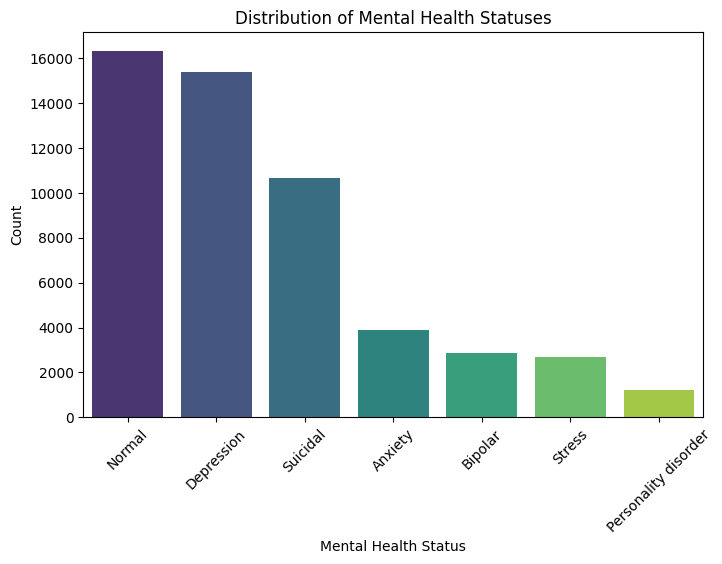

In [13]:
# 1. Distribution of Mental Health Statuses
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='status', order=df['status'].value_counts().index, palette='viridis')
plt.title("Distribution of Mental Health Statuses")
plt.xlabel("Mental Health Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

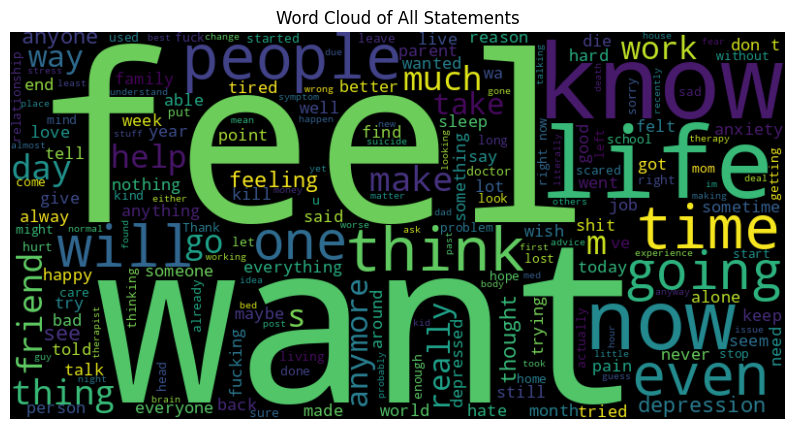

In [14]:
# 2. Word Cloud for the Most Frequent Words in Statements
all_text = " ".join(statement for statement in df['statement'].astype(str))

plt.figure(figsize=(10, 6))
wordcloud = WordCloud(width=800, height=400, background_color="black", colormap="viridis").generate(all_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("Word Cloud of All Statements")
plt.axis("off")
plt.show()

In [15]:
df['text_length'] = df['statement'].astype(str).apply(len)

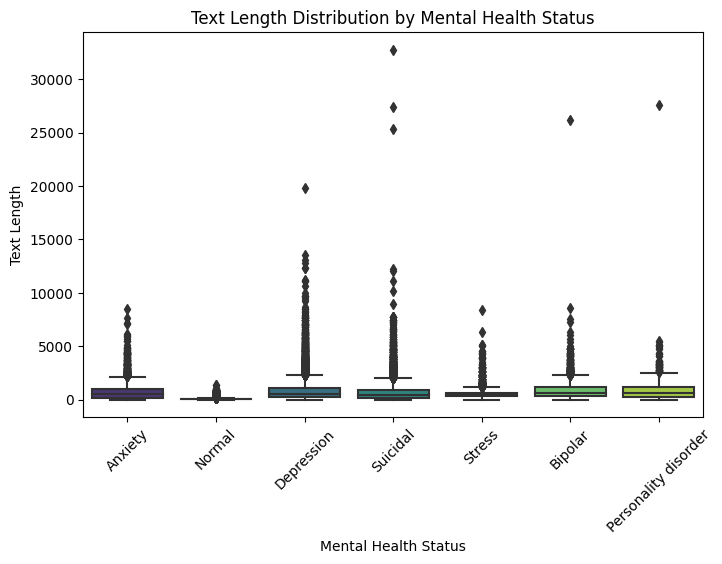

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='status', y='text_length', palette='viridis')
plt.title("Text Length Distribution by Mental Health Status")
plt.xlabel("Mental Health Status")
plt.ylabel("Text Length")
plt.xticks(rotation=45)
plt.show()

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


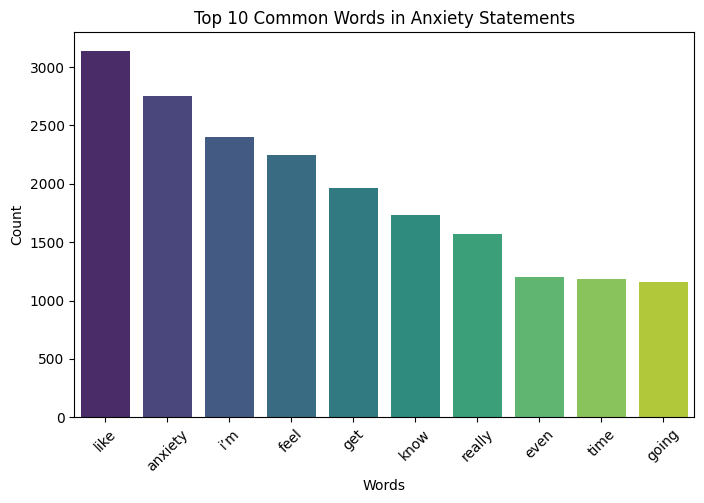

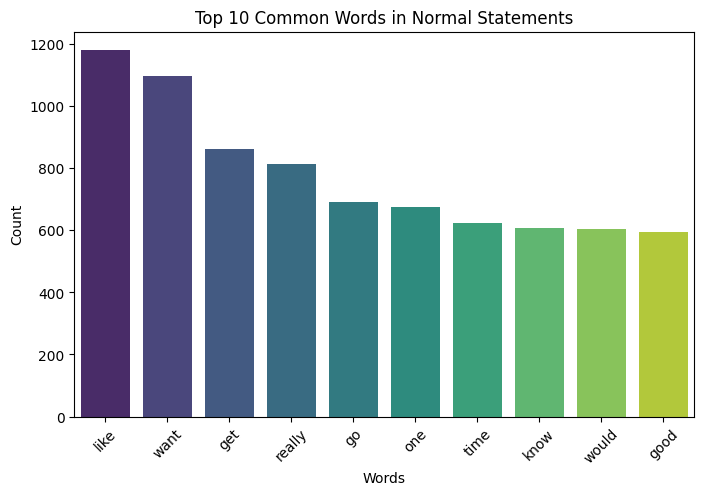

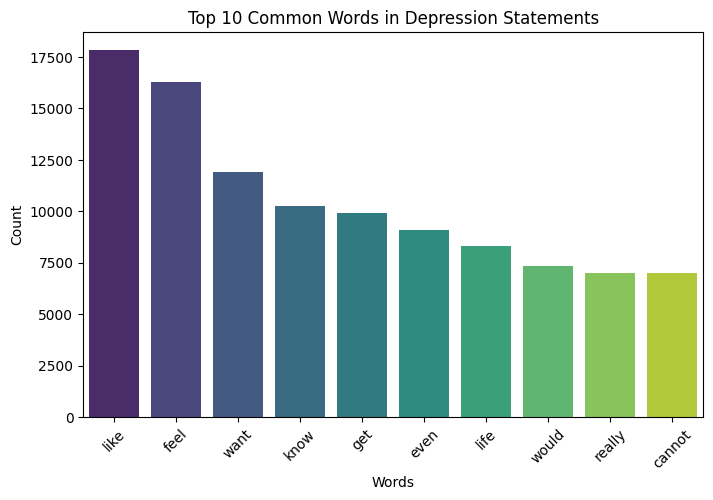

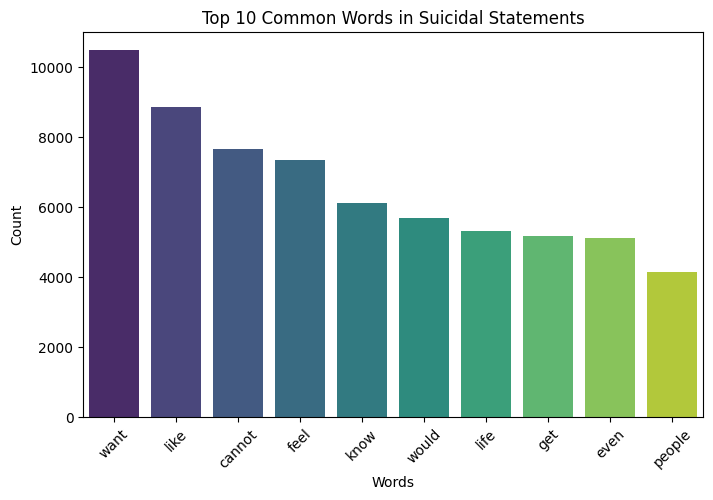

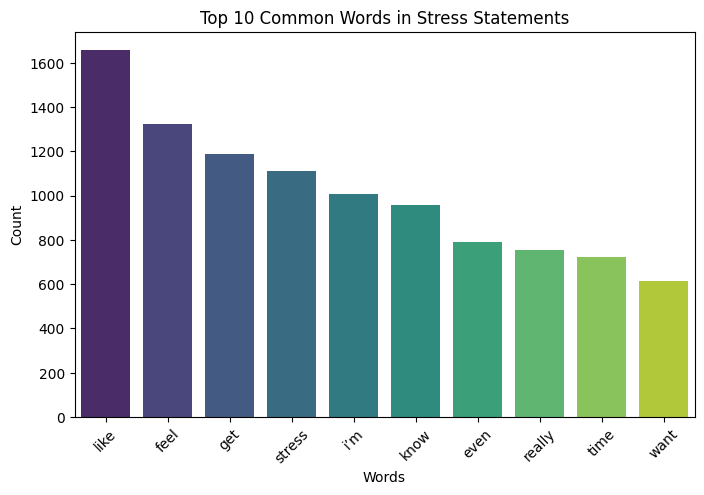

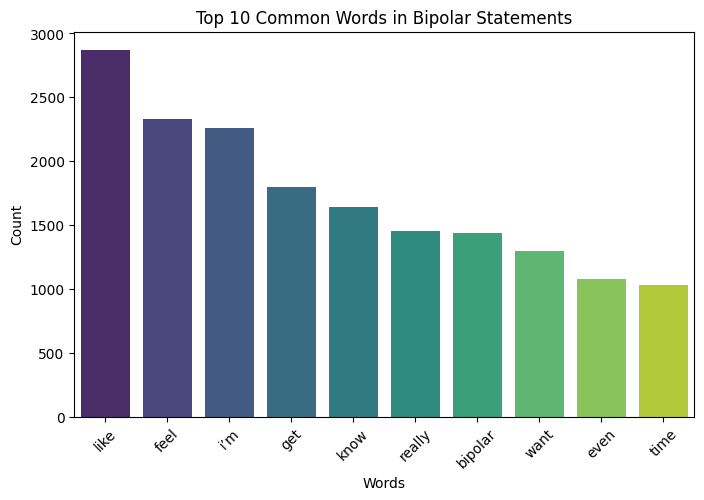

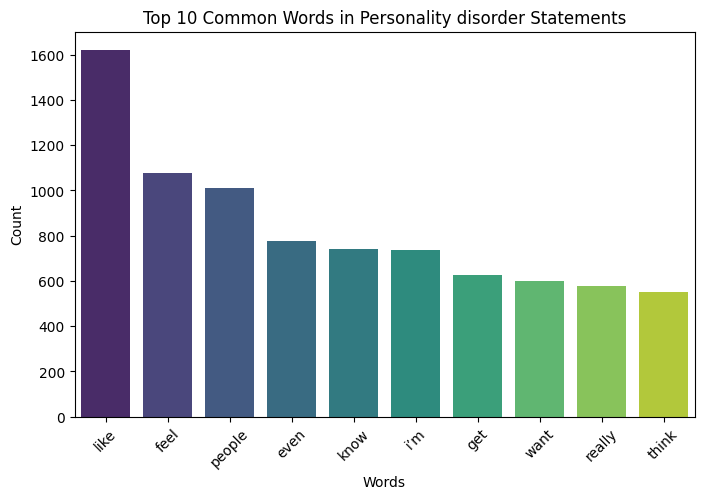

In [17]:
# 4. Most Common Words in Each Status
from collections import Counter
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

def most_common_words(text):
    words = text.lower().split()
    words = [word for word in words if word not in stopwords.words('english')]
    word_counts = Counter(words)
    return word_counts.most_common(10)

for status in df['status'].unique():
    status_text = " ".join(df[df['status'] == status]['statement'].astype(str))
    common_words = most_common_words(status_text)
    words, counts = zip(*common_words)
    
    plt.figure(figsize=(8, 5))
    sns.barplot(x=list(words), y=list(counts), palette='viridis')
    plt.title(f"Top 10 Common Words in {status} Statements")
    plt.xlabel("Words")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

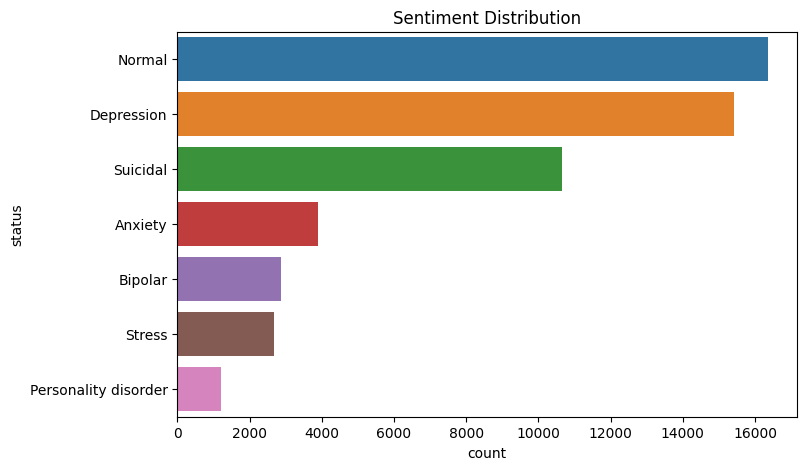

In [18]:
plt.figure(figsize=(8,5)) #to adjust figure size
sns.countplot(y=df["status"], order=df["status"].value_counts().index) #Counter plot, y axis as sentiments with descending order 
plt.title("Sentiment Distribution")
plt.show()

In [19]:
df = df.dropna(subset=['statement'])

In [20]:
print("Missing values before dropping:", df['statement'].isnull().sum())

Missing values before dropping: 0


In [21]:
# Verify the change
print("Missing values after dropping:", df['statement'].isnull().sum())
print("Shape after dropping missing values:", df.shape)

Missing values after dropping: 0
Shape after dropping missing values: (52681, 3)


In [22]:
import re
import string

def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\[.*?\]', '', text)  # Remove text in brackets
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # Remove URLs
    text = re.sub(r'<.*?>+', '', text)  # Remove HTML tags
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)  # Remove punctuation
    text = re.sub(r'\n', '', text)  # Remove new lines
    text = re.sub(r'\w*\d\w*', '', text)  # Remove words containing numbers
    return text

df['statement'] = df['statement'].astype(str).apply(clean_text)


In [23]:
label_encoder = LabelEncoder()
df['status'] = label_encoder.fit_transform(df['status'])


In [24]:
X = df['statement']
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [25]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [26]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)


MultinomialNB()

In [27]:
y_pred_train = model.predict(X_train_tfidf)
print("Training Accuracy:", accuracy_score(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))


Training Accuracy: 0.7097095671981777
              precision    recall  f1-score   support

           0       0.81      0.64      0.72      3086
           1       0.90      0.51      0.65      2250
           2       0.57      0.83      0.67     12388
           3       0.84      0.84      0.84     13035
           4       0.96      0.11      0.20       840
           5       0.91      0.16      0.27      2051
           6       0.75      0.61      0.67      8494

    accuracy                           0.71     42144
   macro avg       0.82      0.53      0.57     42144
weighted avg       0.75      0.71      0.70     42144



In [28]:
y_pred = model.predict(X_test_tfidf)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Test Accuracy: 0.6654645534782196
              precision    recall  f1-score   support

           0       0.80      0.62      0.70       755
           1       0.86      0.46      0.60       527
           2       0.51      0.79      0.62      3016
           3       0.83      0.80      0.81      3308
           4       0.94      0.07      0.13       237
           5       0.84      0.12      0.22       536
           6       0.70      0.54      0.61      2158

    accuracy                           0.67     10537
   macro avg       0.78      0.49      0.53     10537
weighted avg       0.71      0.67      0.65     10537



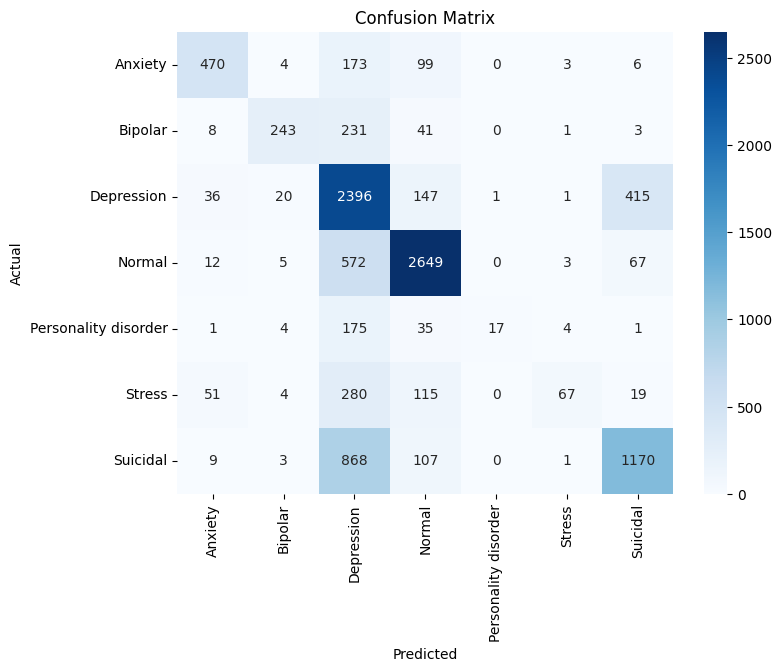

In [29]:
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [30]:
import pickle

pickle.dump(model, open("mental_health_model.pkl", "wb"))
pickle.dump(tfidf, open("tfidf_vectorizer.pkl", "wb"))


In [31]:
loaded_model = pickle.load(open("mental_health_model.pkl", "rb"))
loaded_tfidf = pickle.load(open("tfidf_vectorizer.pkl", "rb"))

sample_text = ["I feel hopeless and sad"]
sample_tfidf = loaded_tfidf.transform(sample_text)
prediction = loaded_model.predict(sample_tfidf)
print("Predicted Status:", label_encoder.inverse_transform(prediction))


Predicted Status: ['Depression']


In [32]:
from sklearn.model_selection import GridSearchCV

param_grid = {'alpha': [0.01, 0.1, 0.5, 1.0]}
grid = GridSearchCV(MultinomialNB(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_tfidf, y_train)
print("Best Parameters:", grid.best_params_)


Best Parameters: {'alpha': 0.1}


In [33]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_train_tfidf, y_train, cv=5)
print("Cross-Validation Scores:", cv_scores)
print("Average CV Accuracy:", np.mean(cv_scores))


Cross-Validation Scores: [0.66496619 0.66223751 0.66852533 0.67006762 0.66694352]
Average CV Accuracy: 0.6665480352004174
